# Cell Analysis Pipeline

Analysis of time-lapse phase-contrast image stacks of round cells/bacteria.

| Step | Description |
|------|-------------|
| 1 | Load image stack |
| 2 | Detect cells in frame 0 using Cellpose |
| 3 | Visualize detections (red X on each cell) |
| 4 | Detect across all frames *(scaffold)* |
| 5 | Track cells over time *(scaffold)* |
| 6 | Statistics and plots *(scaffold)* |
| 7 | Export results *(scaffold)* |

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile

from cell_analysis.segmentation import detect_cells_frame, detect_cells_stack
from cell_analysis.tracking import labels_to_detections, track_cells, compute_track_stats
from cell_analysis.io import save_results

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Load Image Stack

In [2]:
STACK_PATH = "../data/raw/Gradient-0011.zvi  Ch0.tif"

stack = tifffile.imread(STACK_PATH)
print(f"Stack shape: {stack.shape}")
print(f"  Frames: {stack.shape[0]}")
print(f"  Size:   {stack.shape[2]} x {stack.shape[1]}")
print(f"  Dtype:  {stack.dtype}")

Stack shape: (25, 1040, 1388)
  Frames: 25
  Size:   1388 x 1040
  Dtype:  uint16


### Preview: first frame

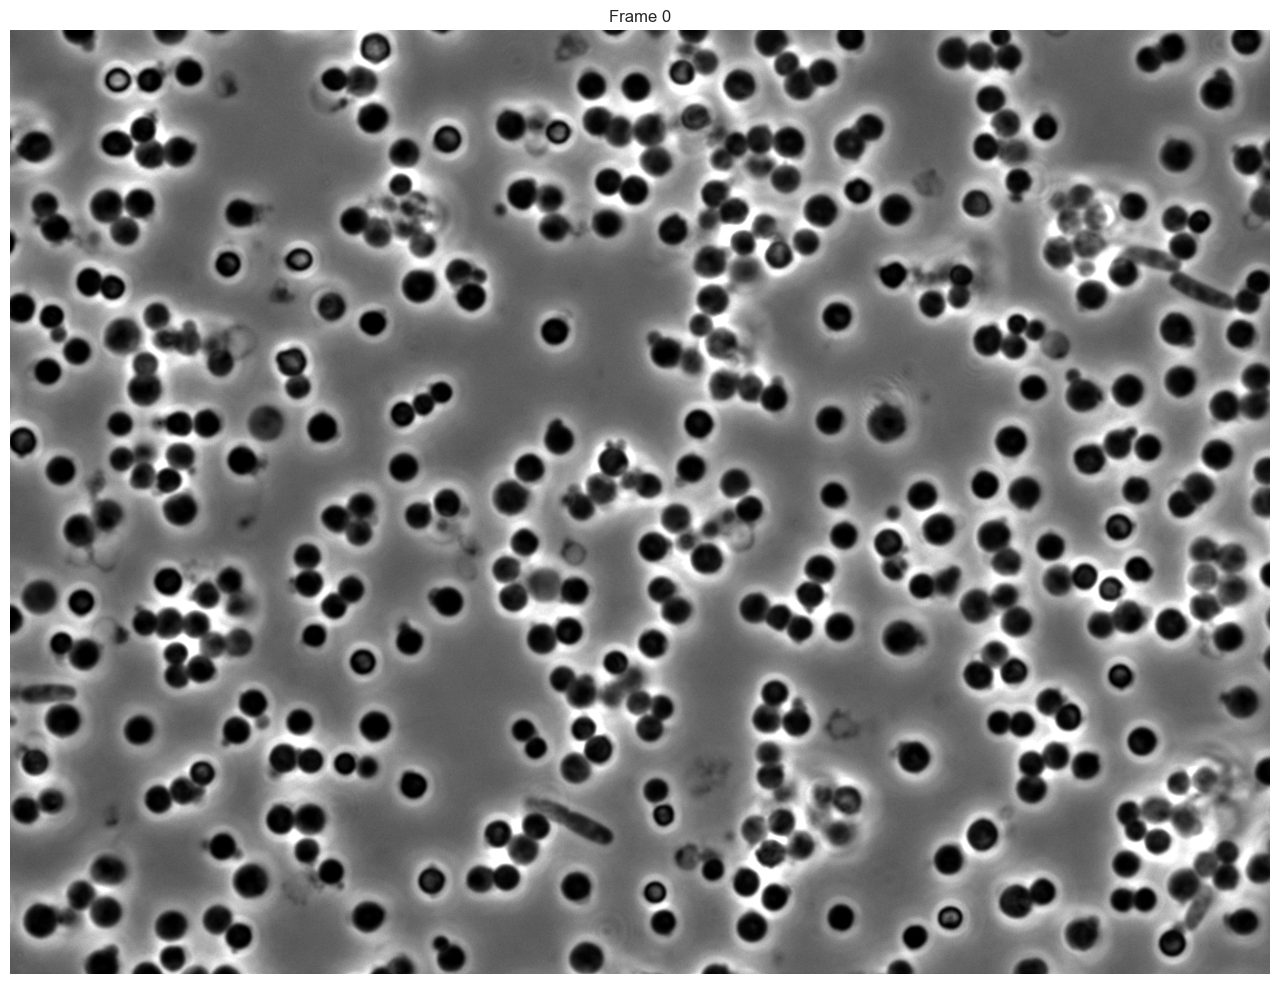

In [3]:
f0 = stack[0]
p1, p99 = np.percentile(f0, [1, 99])

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(f0, cmap="gray", vmin=p1, vmax=p99)
ax.set_title("Frame 0")
ax.axis("off")
plt.tight_layout()

## 2. Detect Cells in Frame 0

Uses Cellpose (deep learning segmentation) with post-filters for area,
circularity, contrast, and edge exclusion.

See [docs/detection_tuning.md](../docs/detection_tuning.md) for full
parameter analysis, method comparison, and known limitations.

In [4]:
# Cellpose detection parameters — see docs/detection_tuning.md for full analysis.
DETECT_PARAMS = dict(
    diameter=32,         # median cell diameter (explicit for stability)
    min_area=300,        # reject debris; median cell ~824 px
    min_circularity=0.7, # reject elongated objects; round cells 0.7-1.0
    min_contrast=1550,   # reject faded/out-of-focus; crisp cells median ~2000
    exclude_edges=True,  # reject cells cut off at frame border
    gpu=True,            # Apple MPS on M3 Max
    resample=False,      # 58x faster; masks resized back in code
)

centroids, labels = detect_cells_frame(f0, **DETECT_PARAMS)
print(f"Detected {len(centroids)} cells in frame 0")

Detected 349 cells in frame 0


## 3. Visualize: Frame 0 with detected cells

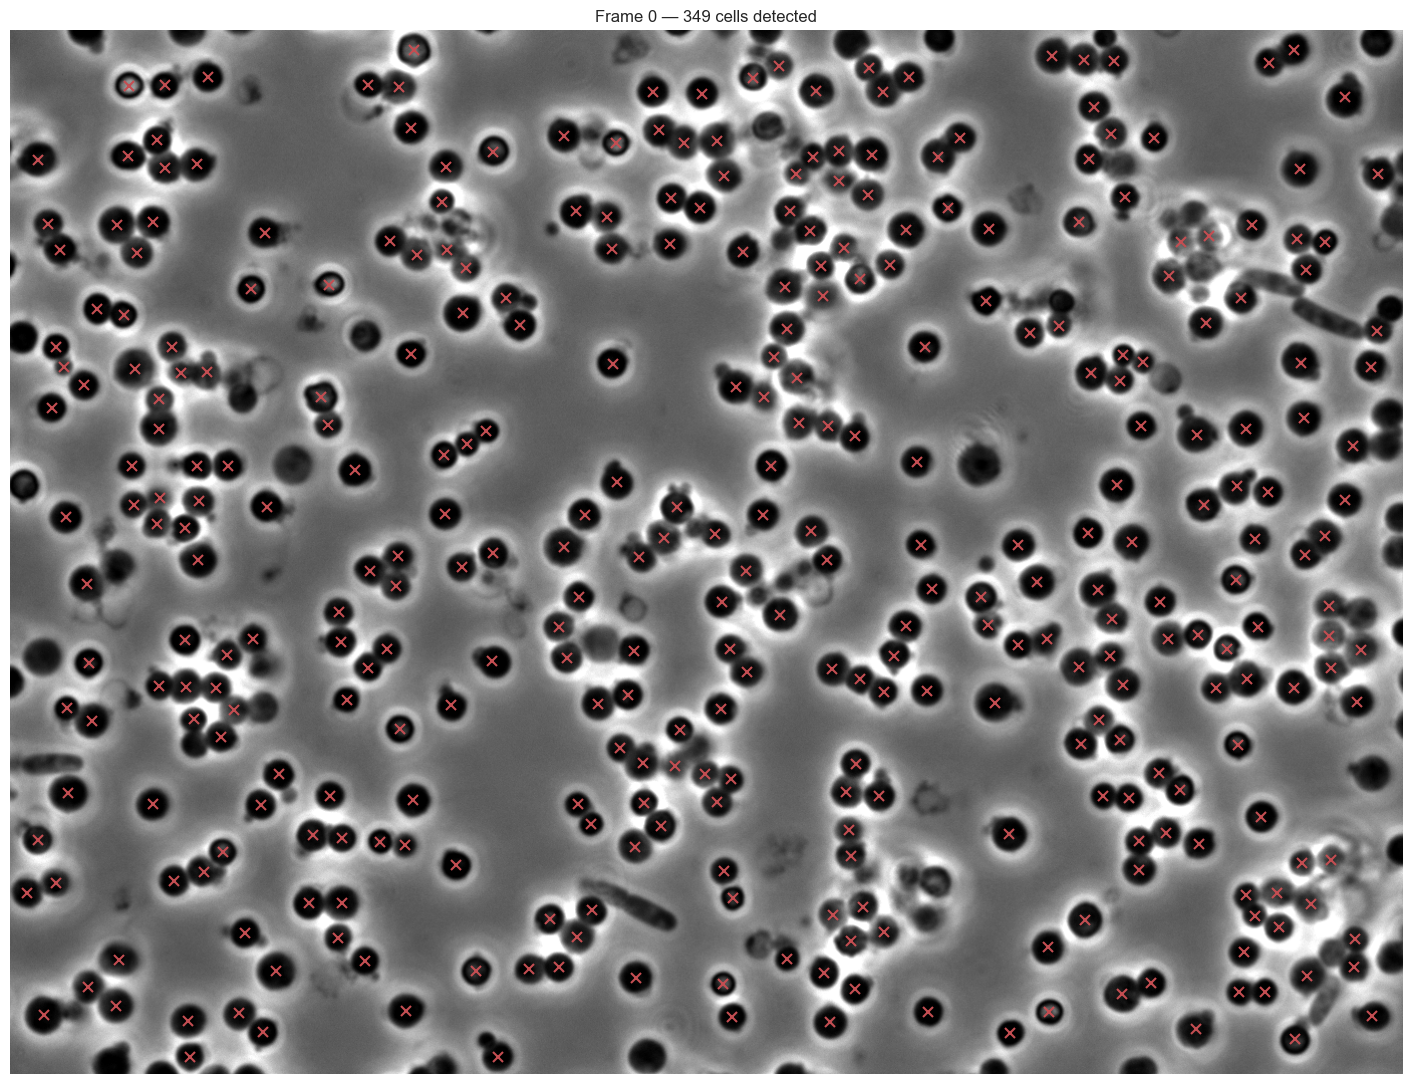

In [5]:
fig, ax = plt.subplots(figsize=(16, 11))
ax.imshow(f0, cmap="gray", vmin=p1, vmax=p99)
ax.plot(
    centroids[:, 1], centroids[:, 0],
    "rx", markersize=7, markeredgewidth=1.5,
)
ax.set_title(f"Frame 0 \u2014 {len(centroids)} cells detected")
ax.axis("off")
plt.tight_layout()

### Zoomed view (dense region)

Adjust the crop coordinates to inspect different parts of the image.

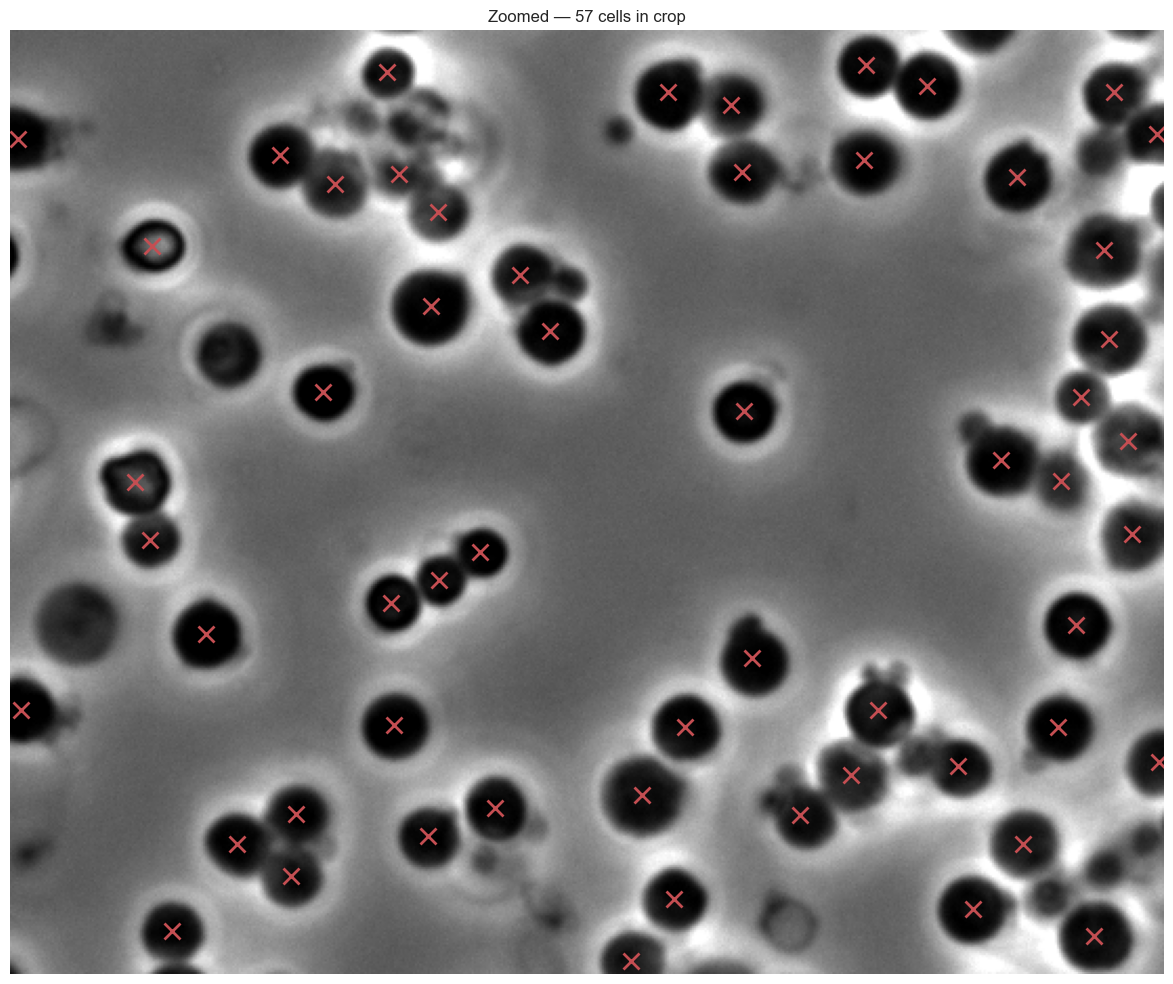

In [6]:
Y_SLICE, X_SLICE = slice(150, 600), slice(250, 800)

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(
    f0[Y_SLICE, X_SLICE], cmap="gray", vmin=p1, vmax=p99,
    extent=[X_SLICE.start, X_SLICE.stop, Y_SLICE.stop, Y_SLICE.start],
)

in_crop = (
    (centroids[:, 0] >= Y_SLICE.start) & (centroids[:, 0] < Y_SLICE.stop)
    & (centroids[:, 1] >= X_SLICE.start) & (centroids[:, 1] < X_SLICE.stop)
)
c = centroids[in_crop]
ax.plot(c[:, 1], c[:, 0], "rx", markersize=12, markeredgewidth=2)
ax.set_title(f"Zoomed \u2014 {in_crop.sum()} cells in crop")
ax.axis("off")
plt.tight_layout()

---

## 4. Detect Cells Across All Frames

*Runs Cellpose on each of the 25 frames. This takes several minutes on CPU.*

In [7]:
centroids_all, label_stack = detect_cells_stack(stack, **DETECT_PARAMS)

  Frame  0: 349 cells
  Frame  1: 340 cells
  Frame  2: 359 cells
  Frame  3: 353 cells
  Frame  4: 353 cells
  Frame  5: 356 cells
  Frame  6: 348 cells
  Frame  7: 342 cells
  Frame  8: 344 cells
  Frame  9: 342 cells
  Frame 10: 341 cells
  Frame 11: 336 cells
  Frame 12: 324 cells
  Frame 13: 321 cells
  Frame 14: 312 cells
  Frame 15: 300 cells
  Frame 16: 285 cells
  Frame 17: 272 cells
  Frame 18: 250 cells
  Frame 19: 235 cells
  Frame 20: 220 cells
  Frame 21: 196 cells
  Frame 22: 198 cells
  Frame 23: 190 cells
  Frame 24: 184 cells


## 5. Track Cells Over Time

| Parameter | Description |
|-----------|-------------|
| `search_range` | Max pixels a cell can move between frames |
| `memory` | Frames a cell can vanish and still be re-linked |

In [8]:
SEARCH_RANGE = 30.0
MEMORY = 3

detections = labels_to_detections(label_stack)
print(f"Total detections across all frames: {len(detections)}")

tracked = track_cells(detections, search_range=SEARCH_RANGE, memory=MEMORY)
print(f"Unique tracks: {tracked['track_id'].nunique()}")

track_stats = compute_track_stats(tracked)
print(f"Cells that disappeared before last frame: {track_stats['disappeared'].sum()}")

Frame 24: 184 trajectories present.
Unique tracks: 404
Cells that disappeared before last frame: 220


## 6. Statistics and Plots

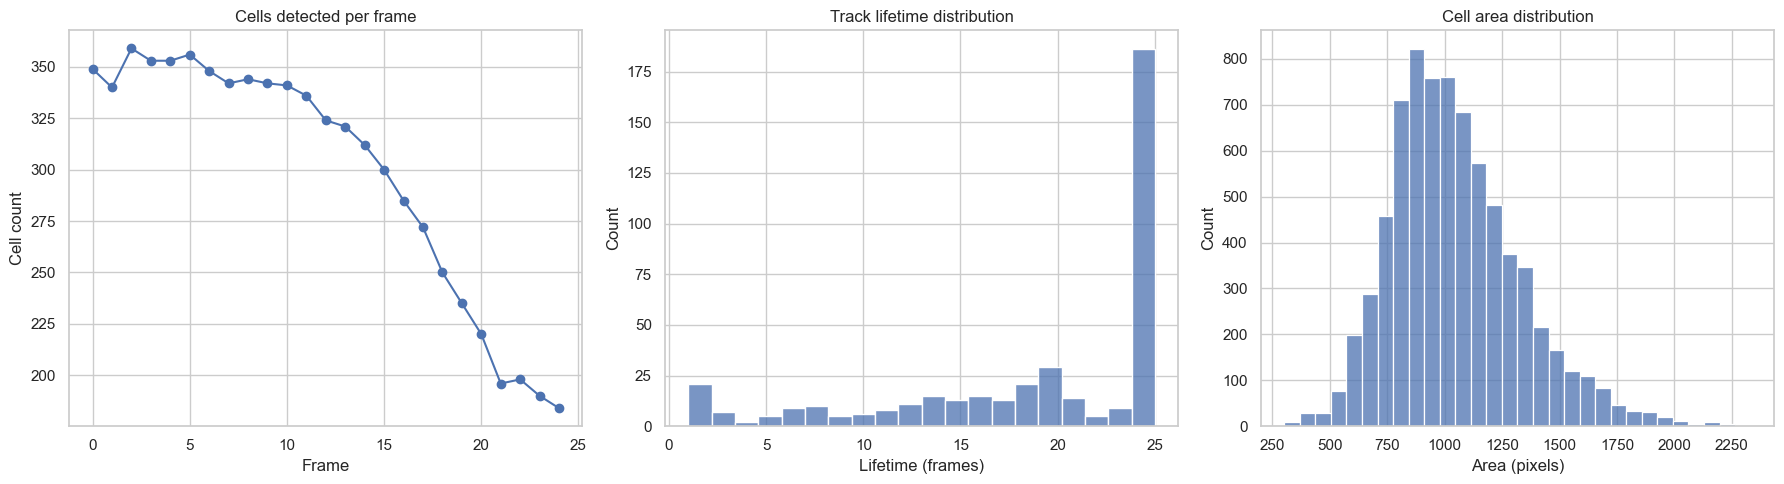

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cells_per_frame = tracked.groupby("frame")["track_id"].nunique()
axes[0].plot(cells_per_frame.index, cells_per_frame.values, "o-")
axes[0].set(xlabel="Frame", ylabel="Cell count", title="Cells detected per frame")

sns.histplot(track_stats["lifetime"], bins=20, ax=axes[1])
axes[1].set(xlabel="Lifetime (frames)", ylabel="Count", title="Track lifetime distribution")

sns.histplot(tracked["area"], bins=30, ax=axes[2])
axes[2].set(xlabel="Area (pixels)", ylabel="Count", title="Cell area distribution")

plt.tight_layout()

### Disappearance events

Cells whose tracks end before the last frame.

In [10]:
disappeared = track_stats[track_stats["disappeared"]].sort_values("last_frame")
print(f"{len(disappeared)} cells disappeared before the final frame")
disappeared

220 cells disappeared before the final frame


,track_id,first_frame,last_frame,mean_area,num_detections,lifetime,disappeared
98,98,0,0,704.000000,1,1,True
0,0,0,1,1075.500000,2,2,True
363,363,1,1,635.000000,1,1,True
237,237,0,1,894.000000,2,2,True
366,366,1,1,741.000000,1,1,True
...,...,...,...,...,...,...,...
135,135,0,23,1129.541667,24,24,True
147,147,0,23,962.086957,23,24,True
399,399,17,23,1004.666667,3,7,True
284,284,0,23,805.681818,22,24,True


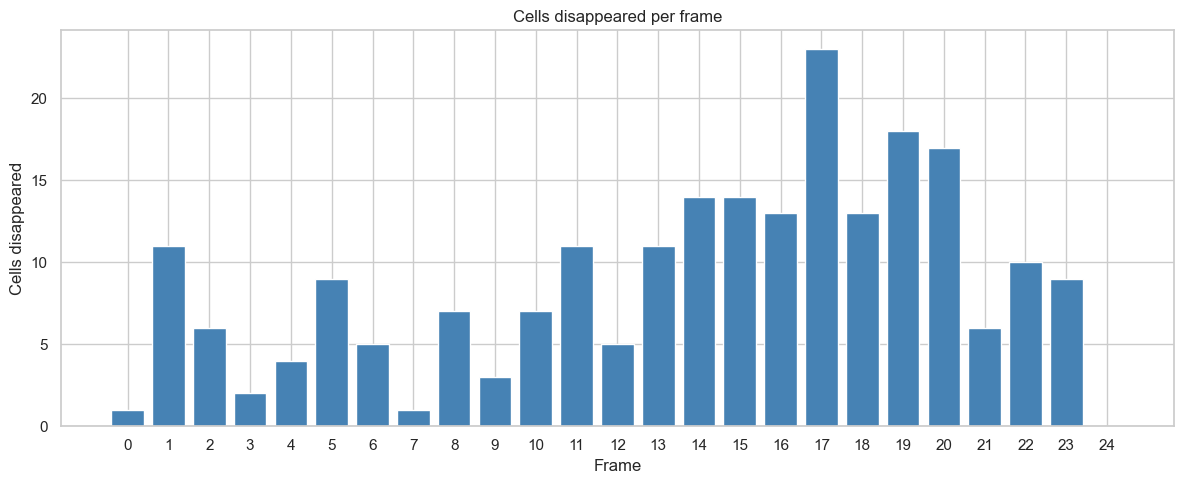

In [11]:

# Count disappearances per frame (tracks whose last_frame < final frame)
last_frame = tracked["frame"].max()
vanished = track_stats[track_stats["last_frame"] < last_frame]
disappearances = vanished.groupby("last_frame").size()

# Reindex so every frame appears (0 disappearances shown explicitly)
disappearances = disappearances.reindex(range(last_frame + 1), fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(disappearances.index, disappearances.values, color="steelblue", edgecolor="white")
ax.set(
    xlabel="Frame",
    ylabel="Cells disappeared",
    title="Cells disappeared per frame",
)
ax.set_xticks(range(0, last_frame + 1))
plt.tight_layout()


## 7. Export Results

In [12]:
from pathlib import Path
from IPython.display import display, FileLink

for df, name in [(tracked, "tracked_cells.csv"), (track_stats, "track_statistics.csv")]:
    path = Path("../results") / name
    save_results(df, str(path))
    display(FileLink(str(path)))

/Users/vvetshte/Projects/temp/experiments_image/results/tracked_cells.csv

/Users/vvetshte/Projects/temp/experiments_image/results/track_statistics.csv